In [12]:
!uname -m

x86_64


In [2]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
# from tqdm import tqdm
from IPython.display import Audio
# import tensorflow as tf
import scipy.io.wavfile as wavfile
from scipy.signal import resample
import parselmouth
from parselmouth.praat import call


## Preprocess Data

In [6]:
#Convert categorical variables
# df = pd.read_csv('data_mini.csv')
df = pd.read_csv('data_full.csv')
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1})
df['qxr_radiologist'] = df['qxr_radiologist'].map({'Normal': 0, 'Abnormal': 1})
df['Diabetes'] = df['Diabetes'].map({'Non Diabetic': 0, 'Diabetic': 1})
df[['Breathsounds','Breathdifficulty', 'Priortb', 'Hemoptysis', 'Weightloss', 'Smokedinlastweek', 'Fever', 'Nightsweats']] = df[['Breathsounds','Breathdifficulty', 'Priortb', 'Hemoptysis', 'Weightloss', 'Smokedinlastweek', 'Fever', 'Nightsweats']].apply(lambda x: x.map({'Yes': 1, 'No': 0}))
df['BMI'] = np.round(df['Weight'] / (.01 * df['Height']) ** 2, 2)
if (df['qxr_radiologist'].isnull().any()).any():
    print("NA values exist: \n", (df.isnull().any()))
    df = df.dropna(subset=['qxr_radiologist'])
print("Class Balance: ", df['qxr_radiologist'].value_counts())
df.head()

NA values exist: 
 Country             False
StudyID             False
Sex                 False
Age                 False
Height              False
Weight              False
Diabetes            False
HIVstatus            True
Durationofcough     False
Priortb              True
Hemoptysis          False
Heartrate           False
Temperature         False
Weightloss          False
Smokedinlastweek    False
Fever               False
Nightsweats         False
Breathsounds        False
Breathdifficulty    False
qxr_radiologist      True
audio_file          False
BMI                 False
dtype: bool
Class Balance:  qxr_radiologist
1.0    577
0.0    501
Name: count, dtype: int64


,Country,StudyID,Sex,Age,Height,Weight,Diabetes,HIVstatus,Durationofcough,Priortb,...,Temperature,Weightloss,Smokedinlastweek,Fever,Nightsweats,Breathsounds,Breathdifficulty,qxr_radiologist,audio_file,BMI
0,PH,R2D2011001,1,47,158.5,70.0,0,Negative,21,1.0,...,36.8,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011001_23_12_06_08_12_15_XA_XI.WAV,27.86
1,PH,R2D2011002,1,41,150.0,48.5,0,Negative,0,0.0,...,36.8,0,0,0,0,0,0,1.0,Merged/Rec_R2D2011002_23_12_07_14_39_31_XA_M20...,21.56
2,PH,R2D2011003,0,50,157.0,54.5,1,Negative,30,1.0,...,36.7,1,1,0,1,1,0,1.0,Merged/Rec_R2D2011003_23_12_11_14_58_49_XA_M20...,22.11
3,PH,R2D2011007,0,48,179.0,79.5,0,Negative,240,0.0,...,37.0,1,1,1,1,1,1,1.0,Merged/Rec_R2D2011007_23_12_13_15_27_18_XA_M20...,24.81
4,PH,R2D2011009,1,63,151.5,62.9,0,Negative,30,0.0,...,36.7,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011009_23_12_13_15_52_58_XA_M20...,27.40


## Feature Extraction

In [59]:
SAMPLING_RATE = 16000 #or 16000
DURATION = 10

# Try out different sampling rates after
# Nyquist-Shannon Sampling Thm: The minimum sampling rate should be at least twice the highest frequency you want to capture in your signal to avoid aliasing

In [60]:
from scipy.signal import butter, filtfilt

def preprocess_audio(file_path, SAMPLING_RATE):
    """
    Load and preprocess audio files for analysis
    """
    audio, sr = librosa.load(file_path, sr=SAMPLING_RATE, mono=True) #Got rid of duration
    
    # Apply Bandpass filter (50-7500Hz)
    nyquist = 0.5 * sr
    low = 100 / nyquist
    high = 7500 / nyquist
    b, a = butter(5, [low, high], btype='band')
    audio_filtered = filtfilt(b, a, audio)
    
    # Segment the audio to isolate individual coughs (top_db < 25 considered silence)
    cough_segments = librosa.effects.split(audio_filtered, top_db=21) #21 for SR of 16000, 
    cough_audio = [audio_filtered[start:end] for start, end in cough_segments]
    
    return cough_audio, sr

## Check Cough Segments

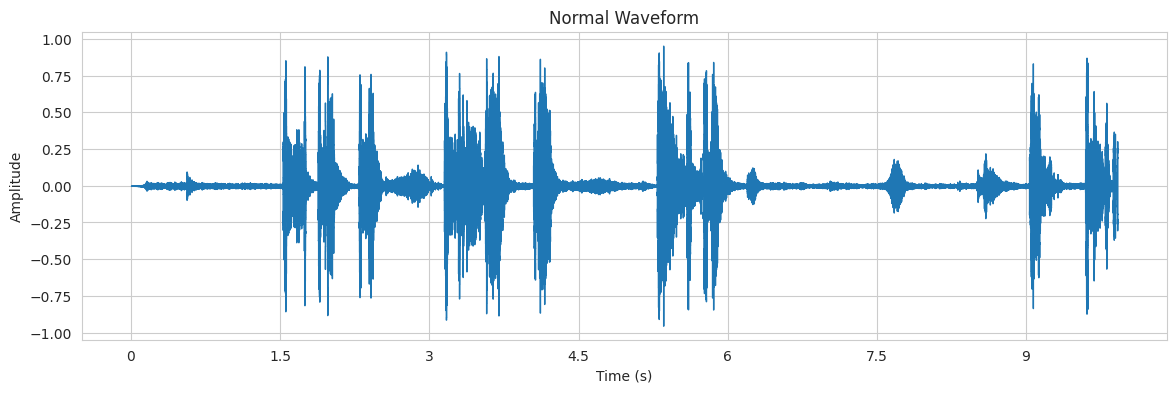

Number of cough segments detected: 11
[10752, 5120, 2048, 11776, 5120, 12288, 2048, 2048, 2560, 5120, 6137]


In [51]:
sample_audio_abnormal= 'Merged/Rec_R2D202955_24_02_22_02_02_07_XA_OP.WAV'
audio, sample_rate = librosa.load(sample_audio_abnormal, sr=None)
# from manual hearing 6 coughs
Audio(data=audio, rate=sample_rate)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Normal Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

cough_audio, sr = preprocess_audio(sample_audio_abnormal, SAMPLING_RATE)
print(f"Number of cough segments detected: {len(cough_audio)}")
print([len(audio) for audio in cough_audio])

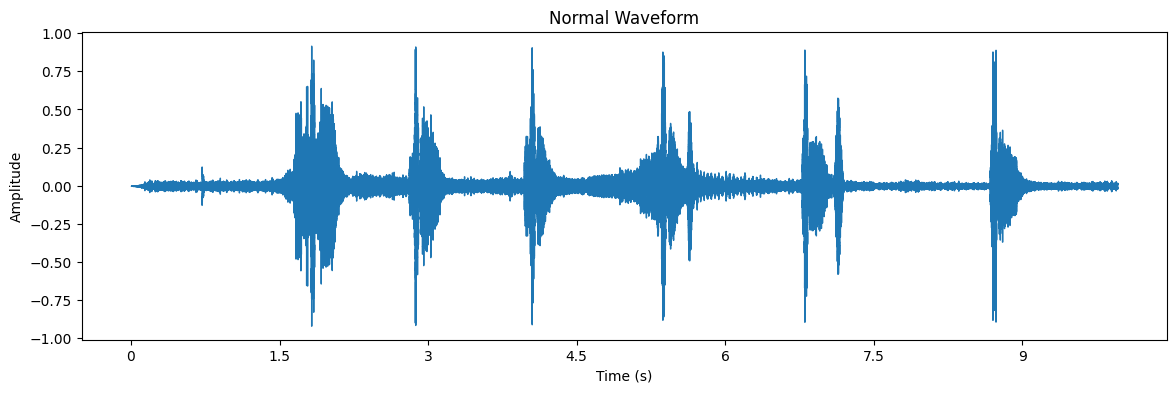

Number of cough segments detected: 4
[2048, 81920, 8704, 6656]


In [28]:
sample_audio_abnormal= 'Merged/Rec_R2D202923_24_01_11_01_01_16_XA_OP.WAV'
audio, sample_rate = librosa.load(sample_audio_abnormal, sr=None)
# from manual hearing 6 coughs
Audio(data=audio, rate=sample_rate)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Normal Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

cough_audio, sr = preprocess_audio(sample_audio_abnormal, SAMPLING_RATE)
print(f"Number of cough segments detected: {len(cough_audio)}")
print([len(audio) for audio in cough_audio])

Normal Result

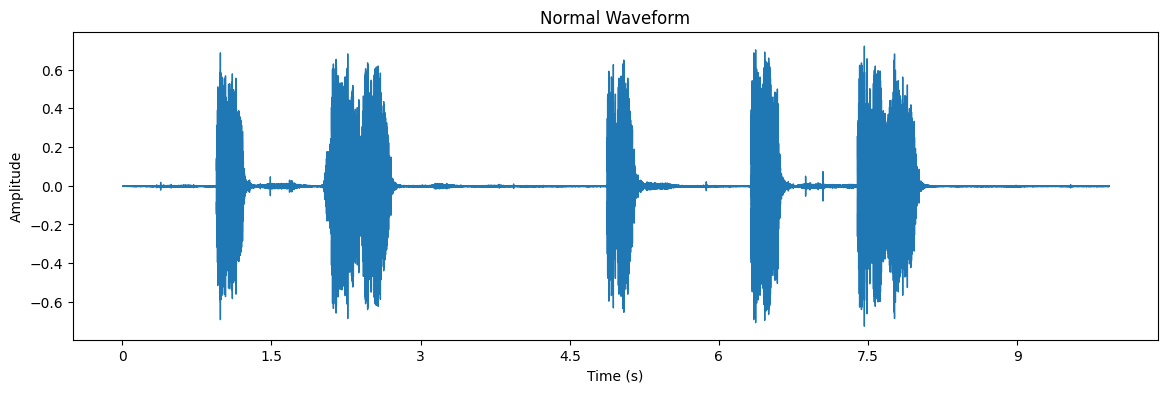

Number of cough segments detected: 5
[6144, 11264, 6144, 6656, 11264]


In [36]:
sample_audio_normal= 'Merged/Rec_R2D201815_23_08_15_05_08_17_XA_XI.WAV'
audio, sample_rate = librosa.load(sample_audio_normal, sr=None)
# from manual hearing 12 coughs

plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Normal Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

cough_audio, sr = preprocess_audio(sample_audio_normal, SAMPLING_RATE)
print(f"Number of cough segments detected: {len(cough_audio)}")
print([len(seg) for seg in cough_audio])

Abnormal Result

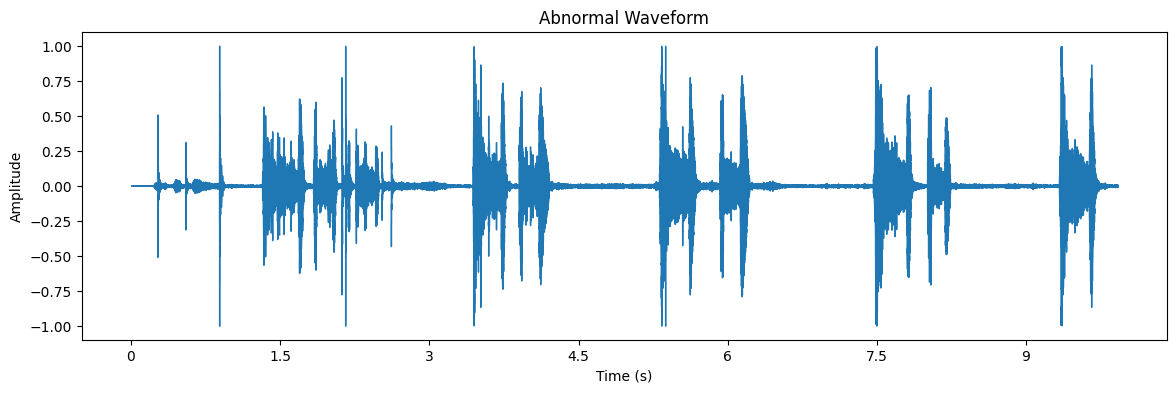

Number of cough segments detected: 9


In [21]:
sample_audio_abnormal = 'Uganda/r2d2.uganda@gmail.com/R2D2041282/Rec_R2D2041282_23_11_09_10_11_36_XA_SA.WAV'
#manual hearing 9 coughs
y, sr = librosa.load(sample_audio_abnormal, sr=None)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Abnormal Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
cough_audio, sr = preprocess_audio(sample_audio_abnormal, SAMPLING_RATE)
print(f"Number of cough segments detected: {len(cough_audio)}")

In [22]:
[len(seg) for seg in cough_audio] #Check lengths of segments

[2048, 2048, 20992, 13824, 7168, 6144, 7680, 5632, 7680]

## Feature Extraction

In [30]:
# https://ieeexplore.ieee.org/document/9413989
from scipy.stats import entropy, kurtosis, skew
import parselmouth
from parselmouth.praat import call

def extract_audio_features(audio, sr=SAMPLING_RATE):
    """
    Extract multiple types of audio features for robust classification
    """

    N_FFT = 128
    HOP_LENGTH = 64 #or 64
    N_MELS = 20
    N_MFCC = 20

    if len(audio) < N_FFT:
        print("short")

    features = {}

    snd = parselmouth.Sound(audio, sampling_frequency=sr)
    # pitch object (for jitter/shimmer)
    point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

    # basic voice-quality measures
    jitter_local   = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    shimmer_local  = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    hnr            = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr_mean       = call(hnr, "Get mean", 0, 0)

    # formants via Burg’s method
    formant = call(snd, "To Formant (burg)", 0.0, 4, 5500, 0.025, 50)
    # average over segment
    formant_means = [call(formant, "Get mean", i, 0, 0, "Hertz") 
                     for i in range(1, 5)]  # F1–F4

    features.update({
        "jitter": jitter_local,
        "shimmer": shimmer_local,
        "hnr": hnr_mean,
        **{f"F{i}": formant_means[i-1] for i in range(1,5)}
    })


    # 1. MFCC Features (13 coefficients + derivatives)
    # print("Extracting MFCC features...")
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    
    # Statistical measures of MFCCs, extract fro each coefficient
    # 78 features
    features.update({
        'mfcc_mean': np.mean(mfccs, axis=1),
        'mfcc_std': np.std(mfccs, axis=1),
        'mfcc_delta_mean': np.mean(mfcc_delta, axis=1),
        'mfcc_delta_std': np.std(mfcc_delta, axis=1),
        'mfcc_delta2_mean': np.mean(mfcc_delta2, axis=1),
        'mfcc_delta2_std': np.std(mfcc_delta2, axis=1)
    })
    
    # 2. Spectral Features
    # print("Extracting Spectral features...")
    spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectral_flatness = librosa.feature.spectral_flatness(y=audio, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]

    features.update({
        'spectral_centroid_mean': np.mean(spectral_centroids),
        'spectral_centroid_std': np.std(spectral_centroids),
        'spectral_bandwidth_mean': np.mean(spectral_bandwidth),
        'spectral_bandwidth_std': np.std(spectral_bandwidth),
        'spectral_rolloff_mean': np.mean(spectral_rolloff),
        'spectral_rolloff_std': np.std(spectral_rolloff),
        'spectral_contrast_mean': np.mean(spectral_contrast, axis=1), #7 default
        'spectral_contrast_std': np.std(spectral_contrast, axis=1),
        'spectral_flatness_mean': np.mean(spectral_flatness),
        'spectral_flatness_std': np.std(spectral_flatness),
    })
    
    # 3. Rhythm and Temporal Features
    # print("Extracting Rhythm and Temporal features...")
    zero_crossing_rate = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
    rms_energy = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]

    features.update({
        'zcr_mean': np.mean(zero_crossing_rate),
        'zcr_std': np.std(zero_crossing_rate),
        'rms_energy_mean': np.mean(rms_energy), 
        'rms_energy_std': np.std(rms_energy),
    })
    
    # 4. Chroma and Tonal Features
    # print("Extracting Chroma and Tonal features...")
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    features.update({
        'chroma_mean': np.mean(chroma, axis=1), #12 one per chroma bin
        'chroma_std': np.std(chroma, axis=1)
    })
    
    # 5. Energy and Power Features
    # 4 features
    # print("Extracting Energy and Power features...")
    features.update({
        'total_energy': np.sum(audio**2),
        'max_amplitude': np.max(np.abs(audio))
    })
    
    # 6. Mel-scale Features
    # 80 features
    # print("Extracting Mel-scale features...")
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=N_FFT, n_mels=N_MELS)
    mel_features = librosa.power_to_db(mel_spectrogram)
    
    features.update({
        'mel_mean': np.mean(mel_features, axis=1),
        'mel_std': np.std(mel_features, axis=1)
    })
    
    #7. Time-domain features
    # 3 total
    # print("Extracting Time-domain features...")
    features.update({
        'entropy': entropy(np.abs(audio)), 
        'kurtosis': kurtosis(audio),
        'skewness': skew(audio)
    })

    #8. STFT
    stft = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    features.update({
        'stft_mean': np.mean(stft),
        'stft_std': np.std(stft),
        'stft_skew': skew(stft.flatten()),
        'stft_kurtosis': kurtosis(stft.flatten())
    })
    
    return features

def flatten_features(feature_dict, sample_id=None):
    """
    Flatten nested feature dictionary into a single-row DataFrame
    """
    flat_dict = {}
    
    for key, value in feature_dict.items():
        if isinstance(value, np.ndarray):
            for i, v in enumerate(value):
                flat_dict[f"{key}_{i}"] = v
        else:
            flat_dict[key] = value
    
    df = pd.DataFrame([flat_dict])
    if sample_id is not None:
        df.index = [sample_id]
    
    return df

## Load Data

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from tqdm import tqdm

# Feature extraction
all_coughs_df = []
max_length = 5124

skip = 0
keep = 0
segments = dict()

for idx, row in tqdm(df.iterrows(), total=len(df)):
    file_path = row['audio_file']
    # print(file_path)
    label = row['qxr_radiologist']
    subject_id = idx

    # split into cough segments
    cough_segments, sr = preprocess_audio(file_path, SAMPLING_RATE)
    # print(len(cough_segments))
    segments[len(cough_segments)] = segments.get(len(cough_segments), 0) + 1
    for i, segment in enumerate(cough_segments):
        if len(segment) < max_length: #can change lower to keep short coughs
            skip += 1
            continue
        else:
            keep += 1
        features_dict = extract_audio_features(segment, sr)
        feature_df = flatten_features(features_dict)
        feature_df['subject_id'] = subject_id
        feature_df['label'] = label
        feature_df['segment_length'] = len(segment)
        all_coughs_df.append(feature_df)

cough_level_df = pd.concat(all_coughs_df, ignore_index=True)
print(f"Skipped {skip} out of {skip + keep} segments due to length < {max_length}")
# cough_level_df.to_csv('data_segment_mini.csv', index=False)
cough_level_df.to_csv('data_segment_full.csv', index=False)


100%|██████████| 1078/1078 [04:00<00:00,  4.48it/s]


Skipped 3196 out of 8476 segments due to length < 5124


In [ ]:
# ## Load Data - Modified to keep top 5 longest coughs per subject
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split, cross_val_score
# from tqdm import tqdm

# # Feature extraction
# all_coughs_df = []
# max_length = 5124  # Your existing threshold

# skip = 0
# keep = 0
# segments = dict()

# for idx, row in tqdm(df.iterrows(), total=len(df)):
#     file_path = row['audio_file']
#     label = row['qxr_radiologist']
#     subject_id = idx

#     # Split into cough segments
#     cough_segments, sr = preprocess_audio(file_path, SAMPLING_RATE)
#     segments[len(cough_segments)] = segments.get(len(cough_segments), 0) + 1
    
#     # Filter segments by minimum length and get their lengths
#     valid_segments = []
#     for i, segment in enumerate(cough_segments):
#         if len(segment) >= max_length:
#             valid_segments.append((segment, len(segment), i))
#         else:
#             skip += 1
    
#     # Sort by length (descending) and keep top 5 longest
#     valid_segments.sort(key=lambda x: x[1], reverse=True)
#     top_5_segments = valid_segments[:5]  # Keep top 5 longest
    
#     # Extract features for the selected segments
#     for segment, seg_length, original_idx in top_5_segments:
#         keep += 1
#         features_dict = extract_audio_features(segment, sr)
#         feature_df = flatten_features(features_dict)
#         feature_df['subject_id'] = subject_id
#         feature_df['label'] = label
#         all_coughs_df.append(feature_df)

# cough_level_df = pd.concat(all_coughs_df, ignore_index=True)
# print(f"Skipped {skip} segments due to length < {max_length}")
# print(f"Kept {keep} segments (max 5 per subject)")
# print(f"Average segments per subject: {keep / len(df):.1f}")

# # Save the data
# cough_level_df.to_csv('data_segment_mini.csv', index=False)

# print("\nSegments per subject distribution:")
# print(cough_level_df.groupby('subject_id').size().value_counts().sort_index())

# cough_level_df

In [30]:
cough_level_df

,jitter,shimmer,hnr,F1,F2,F3,F4,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,...,entropy,kurtosis,skewness,stft_mean,stft_std,stft_skew,stft_kurtosis,subject_id,label,segment_length
0,0.074447,0.188300,-0.036817,1218.415813,1921.461259,3664.836764,4683.175721,-154.881292,17.084883,-8.962392,...,8.189410,3.684605,-0.005147,0.376177,0.643480,4.577497,32.615058,0,0.0,6656
1,0.081879,0.325525,-2.081945,1238.845526,2232.394476,3690.478051,4765.494069,-156.432152,16.003787,-2.395842,...,8.347608,2.514651,0.057357,0.399249,0.551754,3.691823,28.839548,0,0.0,7168
4,0.054057,0.185199,5.102119,729.208461,2319.264721,3656.545576,4401.329365,-161.920358,46.350278,10.838875,...,8.241191,1.764891,0.534494,0.305478,0.797445,5.031331,30.505904,1,1.0,6144
5,0.037793,0.234498,5.304522,655.408912,1914.983955,3652.630898,4622.853914,-173.988468,43.824354,9.271578,...,8.300143,1.288388,0.067880,0.297114,0.792609,5.916923,44.350928,1,1.0,7168
6,0.045594,0.212568,4.357334,620.747510,1988.915333,3592.063066,4440.753884,-170.881910,45.068954,11.087317,...,8.239884,1.797642,0.237045,0.310396,0.876743,5.714419,40.193926,1,1.0,6656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,0.038450,0.175048,-0.140979,903.667614,2318.060154,3594.284158,5151.622686,-156.589803,23.553054,7.574296,...,8.118001,4.556162,0.177623,0.285727,0.543624,6.077882,56.730786,1092,0.0,6144
5275,0.028236,0.132708,0.413547,925.270509,2406.197128,3708.337180,5111.549439,-143.102587,19.285148,7.000499,...,8.579801,2.543506,0.171483,0.367742,0.565044,4.044941,25.572233,1092,0.0,8704
5276,0.030931,0.074384,1.143333,853.024972,2132.215869,3482.866818,5168.026592,-152.834512,22.834068,5.371222,...,8.107753,4.343724,0.384304,0.270756,0.483002,6.044029,60.670692,1092,0.0,5632
5278,0.040329,0.233073,1.203355,917.668600,2293.274424,3766.207949,5050.366788,-145.135818,26.708047,5.164204,...,8.578133,3.955136,0.164175,0.366458,0.667038,4.864106,33.273677,1092,0.0,9216


In [ ]:
# cough_level_df = pd.read_csv('data_segment_mini.csv')
cough_level_df = pd.read_csv('data_segment_full.csv')

cough_level_df.dropna(inplace=True)
cough_level_df

,jitter,shimmer,hnr,F1,F2,F3,F4,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,...,entropy,kurtosis,skewness,stft_mean,stft_std,stft_skew,stft_kurtosis,subject_id,label,segment_length
0,0.074447,0.188300,-0.036817,1218.415813,1921.461259,3664.836764,4683.175721,-154.881292,17.084883,-8.962392,...,8.189410,3.684605,-0.005147,0.376177,0.643480,4.577497,32.615058,0,0.0,6656
1,0.081879,0.325525,-2.081945,1238.845526,2232.394476,3690.478051,4765.494069,-156.432152,16.003787,-2.395842,...,8.347608,2.514651,0.057357,0.399249,0.551754,3.691823,28.839548,0,0.0,7168
4,0.054057,0.185199,5.102119,729.208461,2319.264721,3656.545576,4401.329365,-161.920358,46.350278,10.838875,...,8.241191,1.764891,0.534494,0.305478,0.797445,5.031331,30.505904,1,1.0,6144
5,0.037793,0.234498,5.304522,655.408912,1914.983955,3652.630898,4622.853914,-173.988468,43.824354,9.271578,...,8.300143,1.288388,0.067880,0.297114,0.792609,5.916923,44.350928,1,1.0,7168
6,0.045594,0.212568,4.357334,620.747510,1988.915333,3592.063066,4440.753884,-170.881910,45.068954,11.087317,...,8.239884,1.797642,0.237045,0.310396,0.876743,5.714419,40.193926,1,1.0,6656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,0.038450,0.175048,-0.140979,903.667614,2318.060154,3594.284158,5151.622686,-156.589803,23.553054,7.574296,...,8.118001,4.556162,0.177623,0.285727,0.543624,6.077882,56.730786,1092,0.0,6144
5275,0.028236,0.132708,0.413547,925.270509,2406.197128,3708.337180,5111.549439,-143.102587,19.285148,7.000499,...,8.579801,2.543506,0.171483,0.367742,0.565044,4.044941,25.572233,1092,0.0,8704
5276,0.030931,0.074384,1.143333,853.024972,2132.215869,3482.866818,5168.026592,-152.834512,22.834068,5.371222,...,8.107753,4.343724,0.384304,0.270756,0.483002,6.044029,60.670692,1092,0.0,5632
5278,0.040329,0.233073,1.203355,917.668600,2293.274424,3766.207949,5050.366788,-145.135818,26.708047,5.164204,...,8.578133,3.955136,0.164175,0.366458,0.667038,4.864106,33.273677,1092,0.0,9216


In [94]:
cough_level_df.isna().sum().sum()

0

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Train-validation split (80-20)
X = cough_level_df.drop(columns=['subject_id', 'label', 'segment_length'])
y = cough_level_df['label']
subjects = cough_level_df['subject_id']

train_subjects, val_subjects = train_test_split(subjects.unique(), test_size=0.2, random_state=42)

train_mask = subjects.isin(train_subjects)
val_mask = subjects.isin(val_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Baseline Classification Models

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import mode
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import loguniform, uniform

# Model training and validation
models = {
    "Random Forest": RandomForestClassifier(n_estimators=151, max_depth=13, min_samples_leaf=3, min_samples_split=8, max_features=None, random_state=42),
    "SVM": SVC(C=1.0, kernel='rbf', probability=True, random_state=42),
    # "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, solver='liblinear', penalty='l1', C=1.88)
}

In [ ]:
val_subjects_df = cough_level_df[val_mask][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

def weighted_mean_probs(group):
    weights = group['segment_length'] / group['segment_length'].sum()  # Normalize weights
    return (group['probability'] * weights).sum()

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # method 1: Averaging Probabilities (for AUC) ---
    
    cough_probs = model.predict_proba(X_val_scaled)[:, 1]
    val_probs_df = pd.DataFrame({
        'subject_id': subjects[val_mask], 
        'probability': cough_probs, 
        'segment_length' : cough_level_df[val_mask]['segment_length'].values})
    
    subject_mean_probs = val_probs_df.groupby('subject_id')['probability'].mean()

    #Try Weighting by longer recordings
    
    subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)
    subject_weighted_probs.name = 'probability'
    
    # Align true labels with predicted probabilities for AUC calculation
    auc_results_df = val_subjects_df.join(subject_weighted_probs).dropna()
    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    print(f"Subject-Level Test AUC Score {name}: {auc_score:.4f}\n")
    
    # method 2: Majority Vote (for Classification Report) ---

    cough_preds = model.predict(X_val_scaled)
    val_preds_df = pd.DataFrame({'subject_id': subjects[val_mask], 'prediction': cough_preds})
    
    # For each subject, find the most frequent prediction (the mode)
    subject_majority_vote = val_preds_df.groupby('subject_id')['prediction'].apply(lambda x: mode(x)[0])

    # Align true labels with the final majority vote prediction
    report_results_df = val_subjects_df.join(subject_majority_vote).dropna()
    y_true_subject = report_results_df['label']
    y_pred_subject = report_results_df['prediction']

    print(f"Subject-Level Classification Report {name} (based on Majority Vote):")
    print(classification_report(y_true_subject, y_pred_subject))

/scratch/sli21/ipykernel_3617526/888452679.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-Level Test AUC Score Random Forest: 0.6639

Subject-Level Classification Report Random Forest (based on Majority Vote):
              precision    recall  f1-score   support

         0.0       0.64      0.48      0.55       112
         1.0       0.55      0.70      0.61       100

    accuracy                           0.58       212
   macro avg       0.59      0.59      0.58       212
weighted avg       0.60      0.58      0.58       212



/scratch/sli21/ipykernel_3617526/888452679.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-Level Test AUC Score SVM: 0.6562

Subject-Level Classification Report SVM (based on Majority Vote):
              precision    recall  f1-score   support

         0.0       0.61      0.46      0.52       112
         1.0       0.52      0.67      0.59       100

    accuracy                           0.56       212
   macro avg       0.57      0.56      0.55       212
weighted avg       0.57      0.56      0.55       212

Subject-Level Test AUC Score Logistic Regression: 0.6809

Subject-Level Classification Report Logistic Regression (based on Majority Vote):
              precision    recall  f1-score   support

         0.0       0.64      0.54      0.58       112
         1.0       0.56      0.66      0.61       100

    accuracy                           0.59       212
   macro avg       0.60      0.60      0.59       212
weighted avg       0.60      0.59      0.59       212



/scratch/sli21/ipykernel_3617526/888452679.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


## Univariate logistic regression

In [24]:
X_train

,mel_std_15,mel_std_16,mel_std_14,spectral_contrast_mean_5,mel_std_9,mel_std_17,mel_std_8,mfcc_std_0,mel_std_10,mel_std_18,...,mfcc_delta2_std_1,mfcc_delta_mean_13,mfcc_delta2_std_11,mfcc_delta_std_5,mfcc_delta_mean_15,chroma_mean_11,mfcc_delta_mean_16,mfcc_delta2_std_5,entropy,mfcc_delta2_std_16
0,19.257506,17.044800,19.905079,14.991208,20.942901,15.469316,19.633466,69.616716,21.172505,16.889180,...,0.804341,0.022155,0.442446,0.625782,0.002951,0.569376,0.010188,0.467666,8.189410,0.219894
1,18.073742,17.063946,18.341605,15.640747,17.661679,21.197682,16.739518,70.403456,18.118955,21.582379,...,1.102901,0.038361,0.375562,0.930283,-0.009941,0.580497,0.005842,0.532718,8.347608,0.221689
4,13.264616,12.598727,13.563784,17.851197,11.797164,10.624974,13.671705,52.483841,8.685272,12.619709,...,0.700358,-0.017263,0.263308,0.700971,-0.019107,0.782797,0.012213,0.421505,8.241191,0.239364
5,20.050873,19.074268,19.442534,15.785910,17.117880,17.966158,15.335244,64.834122,15.018248,18.429997,...,0.907482,-0.015930,0.372854,1.153153,0.007415,0.777328,0.004190,0.589281,8.300143,0.195682
6,17.961714,17.263533,17.516301,16.044831,14.320445,14.870439,13.800942,63.516711,13.258526,16.800367,...,0.806039,0.009382,0.406262,0.876609,-0.045830,0.711279,0.016548,0.509272,8.239884,0.213942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5261,12.338787,12.771704,8.791284,14.796147,11.728834,12.830506,11.839869,40.954175,12.022846,11.247159,...,0.682736,0.003536,0.320043,0.629542,-0.017897,0.696693,0.022850,0.447848,8.479786,0.216105
5262,11.880649,12.694828,9.227672,15.874136,12.283008,11.305568,12.515013,36.411571,10.802228,9.180085,...,0.819941,0.006717,0.300204,0.811180,-0.002804,0.613063,0.011906,0.507597,9.383271,0.199839
5263,12.201991,13.157351,9.789356,15.254108,13.390197,12.620235,13.657210,39.185547,12.372804,10.476150,...,0.705026,0.016722,0.366325,0.806142,-0.004310,0.561791,-0.015963,0.542688,8.559683,0.217493
5264,10.280704,10.432446,8.821376,15.662561,11.074305,8.801090,9.940557,33.356164,10.959479,7.638802,...,0.699656,0.000769,0.283110,0.757099,-0.010069,0.502652,-0.003704,0.462885,9.322205,0.202136


In [7]:
import statsmodels.api as sm

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns.tolist())

selected_features = dict()
alpha = 0.05
for feature in X_train_scaled_df.columns:
    try:
        # 1. Add a constant (intercept) to the feature
        X_const = sm.add_constant(X_train_scaled_df[[feature]])

        # 2. Fit the logistic regression model
        model = sm.Logit(y_train.values, X_const).fit(disp=False)

        # 3. Get the p-value for the feature (the second coefficient)
        p_value = model.pvalues.iloc[1]
        selected_features[feature] = p_value

    except Exception as e:
        # This handles cases where a model fails to converge for a specific feature
        print(f"Skipping feature {feature} due to error: {e}")


Skipping feature spectral_contrast_mean_0 due to error: Singular matrix
Skipping feature spectral_contrast_std_0 due to error: Singular matrix


In [ ]:
sorted_univariate = dict(sorted(selected_features.items(), key=lambda item: item[1]))
selected_features_thresh = [feature for feature, pval in sorted_univariate.items() if pval <= 0.4]
print(len(selected_features_thresh))
selected_features_thresh
with open('features.json', 'w') as f:
    json.dump(selected_features_thresh, f)

# more features hurt the performance generally for this small sample

## Start Here Load Data

In [62]:
# cough_level_df = pd.read_csv('data_segment_mini.csv')
cough_level_df = pd.read_csv('data_segment_full.csv')
cough_level_df.dropna(inplace=True)
cough_level_df

,jitter,shimmer,hnr,F1,F2,F3,F4,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,...,entropy,kurtosis,skewness,stft_mean,stft_std,stft_skew,stft_kurtosis,subject_id,label,segment_length
0,0.074447,0.188300,-0.036817,1218.415813,1921.461259,3664.836764,4683.175721,-154.881292,17.084883,-8.962392,...,8.189410,3.684605,-0.005147,0.376177,0.643480,4.577497,32.615058,0,0.0,6656
1,0.081879,0.325525,-2.081945,1238.845526,2232.394476,3690.478051,4765.494069,-156.432152,16.003787,-2.395842,...,8.347608,2.514651,0.057357,0.399249,0.551754,3.691823,28.839548,0,0.0,7168
4,0.054057,0.185199,5.102119,729.208461,2319.264721,3656.545576,4401.329365,-161.920358,46.350278,10.838875,...,8.241191,1.764891,0.534494,0.305478,0.797445,5.031331,30.505904,1,1.0,6144
5,0.037793,0.234498,5.304522,655.408912,1914.983955,3652.630898,4622.853914,-173.988468,43.824354,9.271578,...,8.300143,1.288388,0.067880,0.297114,0.792609,5.916923,44.350928,1,1.0,7168
6,0.045594,0.212568,4.357334,620.747510,1988.915333,3592.063066,4440.753884,-170.881910,45.068954,11.087317,...,8.239884,1.797642,0.237045,0.310396,0.876743,5.714419,40.193926,1,1.0,6656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,0.038450,0.175048,-0.140979,903.667614,2318.060154,3594.284158,5151.622686,-156.589803,23.553054,7.574296,...,8.118001,4.556162,0.177623,0.285727,0.543624,6.077882,56.730786,1092,0.0,6144
5275,0.028236,0.132708,0.413547,925.270509,2406.197128,3708.337180,5111.549439,-143.102587,19.285148,7.000499,...,8.579801,2.543506,0.171483,0.367742,0.565044,4.044941,25.572233,1092,0.0,8704
5276,0.030931,0.074384,1.143333,853.024972,2132.215869,3482.866818,5168.026592,-152.834512,22.834068,5.371222,...,8.107753,4.343724,0.384304,0.270756,0.483002,6.044029,60.670692,1092,0.0,5632
5278,0.040329,0.233073,1.203355,917.668600,2293.274424,3766.207949,5050.366788,-145.135818,26.708047,5.164204,...,8.578133,3.955136,0.164175,0.366458,0.667038,4.864106,33.273677,1092,0.0,9216


In [42]:
import json
with open("features.json", "r") as f:
    selected_features = json.load(f)

## 1. Baseline: acoustic features only (no demographics)


In [69]:
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(cough_level_df['subject_id'].unique(), test_size=0.2, random_state=42, shuffle=True)

pd.Series(train_idx).to_csv("train_subjects_segment.csv", index=False, header=False)
pd.Series(val_idx).to_csv("val_subjects_segment.csv", index=False, header=False)

In [70]:
# =====================================================================
# 1. Baseline: acoustic features only (no demographics)
# =====================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import mode
from sklearn.preprocessing import RobustScaler

# ---- 1.1 Define feature matrix and labels ----
# Use only acoustic features + basic identifiers
acoustic_features_df = cough_level_df[selected_features + ['subject_id', 'label', 'segment_length']].copy()

X = acoustic_features_df[selected_features]
y = acoustic_features_df['label']
subjects = acoustic_features_df['subject_id']

# ---- 1.2 Subject-wise train/val split ----
# train_subjects, val_subjects = train_test_split(
#     subjects.unique(), test_size=0.2, random_state=42
# )

train_subjects = pd.read_csv('train_subjects_segment.csv', header=None)[0].unique().tolist()
val_subjects = pd.read_csv('val_subjects_segment.csv', header=None)[0].unique().tolist()

train_mask = subjects.isin(train_subjects)
val_mask   = subjects.isin(val_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

# We will need these later for subject-level aggregation
val_subjects_df = acoustic_features_df[val_mask][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

# ---- 1.3 Scale features ----
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# ---- 1.4 Define baseline models ----
baseline_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=151,
        max_depth=13,
        min_samples_leaf=3,
        min_samples_split=8,
        max_features=None,
        random_state=42
    ),
    "SVM": SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='liblinear',
        penalty='l1',
        C=1.88
    )
}

# ---- 1.5 Helper for weighted averaging (optional) ----
def weighted_mean_probs(group):
    # You can change weighting scheme here if you want
    weights = group['segment_length'] / group['segment_length'].sum()
    return (group['probability'] * weights).sum()

# ---- 1.6 Train + evaluate subject-level performance ----
baseline_results_no_demo = {}

for name, model in baseline_models.items():
    print(f"\n==== Baseline (No Demographics) – {name} ====")
    model.fit(X_train_scaled, y_train)

    # --- Subject-level probabilities (AUC) ---
    cough_probs = model.predict_proba(X_val_scaled)[:, 1]

    val_probs_df = pd.DataFrame({
        'subject_id': subjects[val_mask].values,
        'probability': cough_probs,
        'segment_length': acoustic_features_df[val_mask]['segment_length'].values
    })

    # Simple mean across segments:
    subject_mean_probs = val_probs_df.groupby('subject_id')['probability'].mean()

    # Weighted mean (optional):
    subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)
    subject_weighted_probs.name = 'probability'

    # Use weighted or unweighted; here I'll use weighted:
    auc_results_df = val_subjects_df.join(subject_weighted_probs).dropna()
    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    print(f"Subject-level AUC (weighted probs): {auc_score:.4f}")

    y_true_subject = auc_results_df['label']
    y_prob_subject = auc_results_df['probability']
    y_pred_subject = (y_prob_subject >= 0.5).astype(int)

    # --- Subject-level majority vote (for classification report) ---
    # cough_preds = model.predict(X_val_scaled)
    # val_preds_df = pd.DataFrame({
    #     'subject_id': subjects[val_mask].values,
    #     'prediction': cough_preds
    # })
    # subject_majority_vote = (
    #     val_preds_df
    #     .groupby('subject_id')['prediction']
    #     .agg(lambda x: mode(x, keepdims=True).mode[0])
    # )
    # report_results_df = val_subjects_df.join(subject_majority_vote).dropna()
    # print("\nSubject-level classification report (majority vote):")
    # print(classification_report(report_results_df['label'], report_results_df['prediction']))

    baseline_results_no_demo[name] = (y_true_subject, y_pred_subject, y_prob_subject)



==== Baseline (No Demographics) – Random Forest ====


/scratch/sli21/ipykernel_876171/1381557753.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-level AUC (weighted probs): 0.6525

==== Baseline (No Demographics) – SVM ====


/scratch/sli21/ipykernel_876171/1381557753.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-level AUC (weighted probs): 0.6639

==== Baseline (No Demographics) – Logistic Regression ====
Subject-level AUC (weighted probs): 0.7082


/scratch/sli21/ipykernel_876171/1381557753.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


## Add demographics

In [71]:
# =====================================================================
# 2. Baseline: acoustic + demographics
# =====================================================================

# --- 2.1 Define demographic columns (if not already defined above) ---
demo_cols = [
    'Age', 
    'Sex', 
    'Diabetes',
    'BMI', 
    'Breathsounds', 
    'Breathdifficulty',
    'Durationofcough', 
    'Priortb', 
    'Hemoptysis', 
    'Heartrate', 
    'Temperature', 
    'Weightloss', 
    'Smokedinlastweek', 
    'Fever', 
    'Nightsweats'
]

# df is your original recording-level dataframe with these columns
demographics_df = df[demo_cols]

# --- 2.2 Build feature table with acoustic + demographics ---
# Start from the same acoustic_features_df you used above
acoustic_features_df = cough_level_df[selected_features + ['subject_id', 'label', 'segment_length']].copy()

# Merge demographics by subject_id (subject_id aligns with df's index)
features_with_demo_df = acoustic_features_df.merge(
    demographics_df,
    left_on='subject_id',
    right_index=True,
    how='left'
)

# Drop rows with missing demographics if any
features_with_demo_df = features_with_demo_df.dropna()

# --- 2.3 Reuse the same subject split as before ---
# We already loaded train_subjects and val_subjects from CSV above,
# so just mask using those lists again.

subjects_demo = features_with_demo_df['subject_id']
X_demo = features_with_demo_df.drop(columns=['subject_id', 'label', 'segment_length'])
y_demo = features_with_demo_df['label']

train_mask_demo = subjects_demo.isin(train_subjects)
val_mask_demo   = subjects_demo.isin(val_subjects)

X_train_demo, y_train_demo = X_demo[train_mask_demo], y_demo[train_mask_demo]
X_val_demo,   y_val_demo   = X_demo[val_mask_demo],   y_demo[val_mask_demo]

# Subject-level truth table for evaluation (same pattern as before)
val_subjects_demo_df = features_with_demo_df[val_mask_demo][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

# --- 2.4 Scale features ---
scaler_demo = RobustScaler()
X_train_demo_scaled = scaler_demo.fit_transform(X_train_demo)
X_val_demo_scaled   = scaler_demo.transform(X_val_demo)

# --- 2.5 Use the same baseline models dict ---
baseline_results_with_demo = {}

for name, model in baseline_models.items():
    print(f"\n==== Baseline (With Demographics) – {name} ====")
    model.fit(X_train_demo_scaled, y_train_demo)

    # --- Subject-level probabilities (AUC) ---
    cough_probs = model.predict_proba(X_val_demo_scaled)[:, 1]

    val_probs_demo_df = pd.DataFrame({
        'subject_id': subjects_demo[val_mask_demo].values,
        'probability': cough_probs,
        # we can still weight by segment length if you like
        'segment_length': features_with_demo_df[val_mask_demo]['segment_length'].values
    })

    # Weighted mean across segments per subject (same helper as above)
    subject_weighted_probs_demo = (
        val_probs_demo_df
        .groupby('subject_id')
        .apply(weighted_mean_probs)
    )
    subject_weighted_probs_demo.name = 'probability'

    auc_results_demo_df = val_subjects_demo_df.join(subject_weighted_probs_demo).dropna()
    auc_score_demo = roc_auc_score(auc_results_demo_df['label'], auc_results_demo_df['probability'])
    print(f"Subject-level AUC (weighted probs): {auc_score_demo:.4f}")

    y_true_subject_demo = auc_results_demo_df['label']
    y_prob_subject_demo = auc_results_demo_df['probability']
    y_pred_subject_demo = (y_prob_subject_demo >= 0.5).astype(int)

    baseline_results_with_demo[name] = (y_true_subject_demo, y_pred_subject_demo, y_prob_subject_demo)



==== Baseline (With Demographics) – Random Forest ====


/scratch/sli21/ipykernel_876171/640835591.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_probs_demo_df


Subject-level AUC (weighted probs): 0.7937

==== Baseline (With Demographics) – SVM ====


/scratch/sli21/ipykernel_876171/640835591.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_probs_demo_df


Subject-level AUC (weighted probs): 0.7878

==== Baseline (With Demographics) – Logistic Regression ====
Subject-level AUC (weighted probs): 0.8107


/scratch/sli21/ipykernel_876171/640835591.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_probs_demo_df


## Visualizations

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd
import numpy as np

def plot_confusion_matrices(models_results, figsize=(8, 6)):
    """
    Plot confusion matrices for all models
    models_results: dict with model_name: (y_true, y_pred, y_prob)
    """
    n_models = len(models_results)
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, (y_true, y_pred, y_prob)) in enumerate(models_results.items()):
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Normal', 'Abnormal'],
                   yticklabels=['Normal', 'Abnormal'],
                   ax=axes[idx])
        
        axes[idx].set_title(f'{model_name}\nConfusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results_dict, figsize=(6, 4), title="ROC Curves Comparison",
                    save_npz_path=None):
    """
    results_dict: {model_name: (y_true, y_pred, y_prob)}
    If save_npz_path is provided, saves:
      - {model}__y_true, {model}__y_prob, {model}__fpr, {model}__tpr, {model}__thr, {model}__auc
    """
    plt.figure(figsize=figsize)

    pack = {}
    for model_name, (y_true, y_pred, y_prob) in results_dict.items():
        y_true = np.asarray(y_true)
        y_prob = np.asarray(y_prob)

        fpr, tpr, thr = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, linewidth=2.2, label=f'{model_name} (AUC = {roc_auc:.3f})')

        # Save arrays
        safe = model_name.replace(" ", "_").replace("/", "_")
        pack[f"{safe}__y_true"] = y_true
        pack[f"{safe}__y_prob"] = y_prob
        pack[f"{safe}__fpr"] = fpr
        pack[f"{safe}__tpr"] = tpr
        pack[f"{safe}__thr"] = thr
        pack[f"{safe}__auc"] = np.array([roc_auc])

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.8, label='Chance')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right", framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if save_npz_path is not None:
        np.savez(save_npz_path, **pack)
        print(f"✓ Saved ROC arrays to: {save_npz_path}")

    return pack

def calculate_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)  # ✅ Use function arguments
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'PPV (Precision)': ppv,
        'NPV': npv,
        'Accuracy': accuracy,
        'AUC': roc_auc
    }

def create_metrics_table(models_results):
    """
    Create a comprehensive metrics table
    """
    metrics_data = []
    
    for model_name, (y_true, y_pred, y_prob) in models_results.items():
        metrics = calculate_metrics(y_true, y_pred, y_prob)
        metrics['Model'] = model_name
        metrics_data.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_data).set_index('Model')
    
    # Style the dataframe for better display
    styled_df = metrics_df.style.format({
        'Sensitivity (Recall)': '{:.3f}',
        'Specificity': '{:.3f}',
        'PPV (Precision)': '{:.3f}',
        'NPV': '{:.3f}',
        'Accuracy': '{:.3f}',
        'AUC': '{:.3f}'
    }).background_gradient(cmap='RdYlGn', subset=['AUC', 'Accuracy'])
    
    return metrics_df, styled_df

def analyze_performance_by_group(df, subject_results_df, analysis_cols):
    """
    FIXED version: handles single-class subgroups + bins continuous variables
    """
    print(f"\n--- In-depth Performance Analysis ---")
    
    # Merge predictions with subject metadata
    merged = df.merge(
        subject_results_df[['y_true', 'y_pred', 'y_prob']],
        left_index=True,
        right_index=True,
        how='inner'
    )
    
    rows = []
    
    # Overall performance (safe confusion matrix)
    cm = confusion_matrix(merged['y_true'], merged['y_pred'], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    overall_metrics = {
        'Group': 'Overall',
        'Level': 'All',
        'N': len(merged),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'AUC': roc_auc_score(merged['y_true'], merged['y_prob'])
    }
    rows.append(overall_metrics)
    
    # Process each analysis column with binning for continuous vars
    for col in analysis_cols:
        if col not in merged.columns:
            print(f"Warning: {col} not found")
            continue
            
        # BIN CONTINUOUS VARIABLES
        temp_df = merged.copy()
        
        if col in ['Age', 'BMI', 'Durationofcough', 'Heartrate', 'Temperature']:
            if col == 'Age':
                bins = [0, 25, 35, 50, 65, 100]
                labels = ['<25', '25-35', '35-50', '50-65', '65+']
            elif col == 'BMI':
                bins = [0, 18.5, 25, 30, 35, 100]
                labels = ['<18.5', '18.5-25', '25-30', '30-35', '35+']
            elif col == 'Durationofcough':
                bins = [0, 7, 14, 30, 1000]
                labels = ['<1wk', '1-2wk', '2-4wk', '4wk+']
            elif col == 'Heartrate':
                bins = [0, 70, 85, 100, 200]
                labels = ['<70', '70-85', '85-100', '100+']
            elif col == 'Temperature':
                bins = [0, 36.5, 37.5, 38.5, 100]
                labels = ['<36.5', '36.5-37.5', '37.5-38.5', '38.5+']
            
            temp_df[f'{col}_binned'] = pd.cut(temp_df[col], bins=bins, labels=labels, include_lowest=True)
            group_col = f'{col}_binned'
        else:
            group_col = col
            
        # Group analysis
        for level, sub in temp_df.groupby(group_col, observed=True):
            if len(sub) < 2:
                continue
                
            # SAFE confusion matrix with labels=[0,1]
            cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1])
            if cm.sum() == 0:
                continue
                
            tn, fp, fn, tp = cm.ravel()
            
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            accuracy = (tp + tn) / (tp + tn + fp + fn)
            auc = roc_auc_score(sub['y_true'], sub['y_prob']) if sub['y_true'].nunique() == 2 else np.nan

            rows.append({
                'Group': col,
                'Level': str(level),  # Convert to string to handle bin labels
                'N': len(sub),
                'Sensitivity': sensitivity,
                'Specificity': specificity,
                'Accuracy': accuracy,
                'AUC': auc
            })
    
    breakdown_df = pd.DataFrame(rows)
    
    styled_df = breakdown_df.style.format({
        'N': '{:,.0f}',
        'Sensitivity': '{:.3f}',
        'Specificity': '{:.3f}',
        'Accuracy': '{:.3f}',
        'AUC': '{:.3f}'
    }).background_gradient(cmap='RdYlGn', subset=['AUC', 'Sensitivity'])
    
    return breakdown_df, styled_df

def style_breakdown_table(breakdown_df, min_n_for_fade=10):
    """
    Intuitive colors for demographic breakdown tables:
    - Fixed [0,1] color scale for rate metrics
    - Low-N rows are de-emphasized ONLY in non-metric columns
    - Compatible with older pandas versions
    """
    import pandas as pd

    df_show = breakdown_df.copy()

    metric_cols = [c for c in ['AUC', 'Sensitivity', 'Specificity', 'Accuracy'] if c in df_show.columns]
    non_metric_cols = [c for c in df_show.columns if c not in metric_cols]

    # Formatting (with na_rep if supported)
    try:
        styler = df_show.style.format({
            'N': '{:,.0f}',
            'Sensitivity': '{:.3f}',
            'Specificity': '{:.3f}',
            'Accuracy': '{:.3f}',
            'AUC': '{:.3f}'
        }, na_rep="—")
    except TypeError:
        styler = df_show.style.format({
            'N': '{:,.0f}',
            'Sensitivity': '{:.3f}',
            'Specificity': '{:.3f}',
            'Accuracy': '{:.3f}',
            'AUC': '{:.3f}'
        })

    # Fixed normalization for intuitive colors (1.0 always darkest green)
    if metric_cols:
        styler = styler.background_gradient(
            cmap='RdYlGn',
            subset=metric_cols,
            vmin=0, vmax=1
        )

    # Fade only non-metric columns for low-N rows (does NOT fade metric cells)
    def fade_small_n(row):
        styles = [''] * len(row)
        if 'N' in row.index and pd.notna(row['N']) and row['N'] < min_n_for_fade:
            for i, col in enumerate(row.index):
                if col in non_metric_cols:
                    styles[i] = 'opacity: 0.55'
        return styles

    styler = styler.apply(fade_small_n, axis=1)
    return styler


Generating visualizations for all models...

=== ACOUSTIC-ONLY (No Demographics) ===


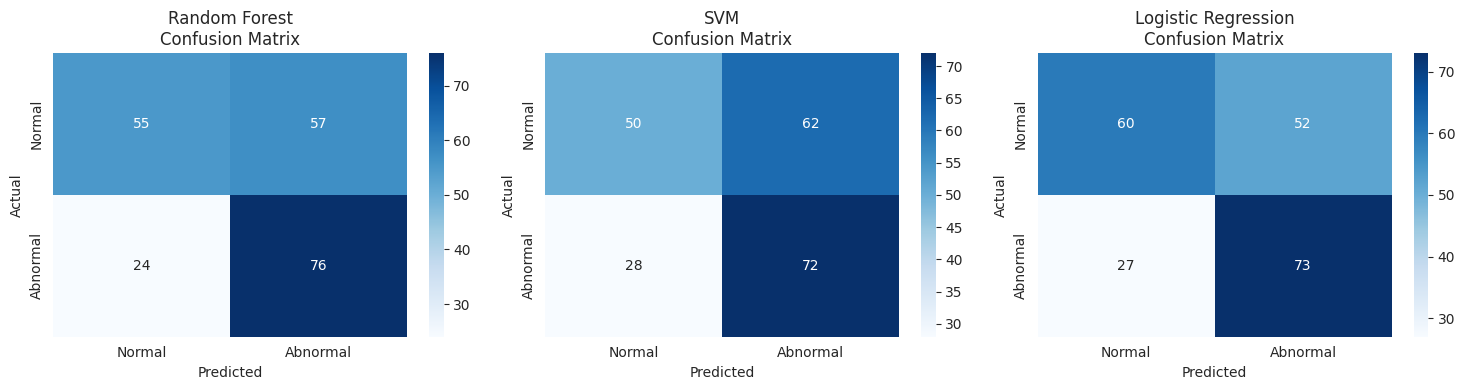

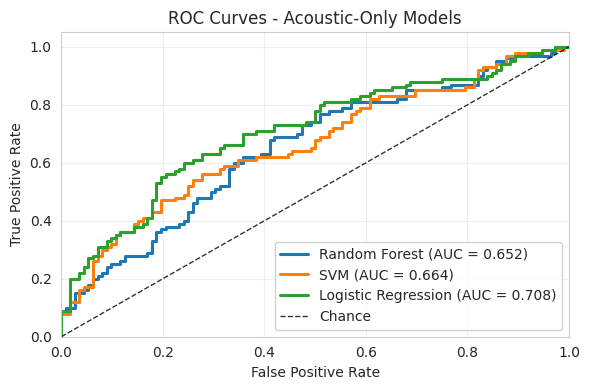

✓ Saved ROC arrays to: roc_segmented_acoustic_only.npz

--- Model Performance Metrics (Acoustic-Only) ---


,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
Random Forest,0.760,0.491,0.571,0.696,0.618,0.652
SVM,0.720,0.446,0.537,0.641,0.575,0.664
Logistic Regression,0.730,0.536,0.584,0.690,0.627,0.708



=== ACOUSTIC + DEMOGRAPHICS ===


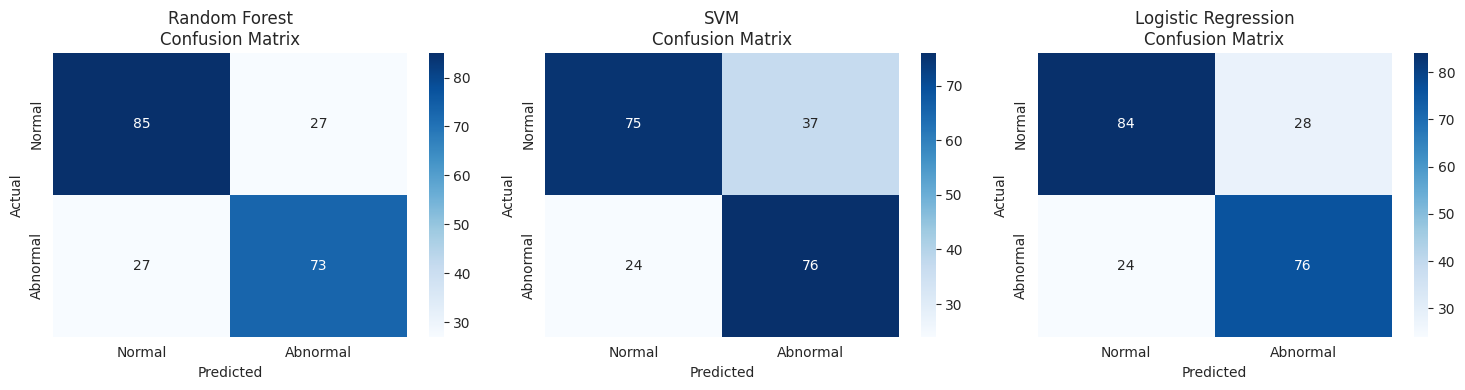

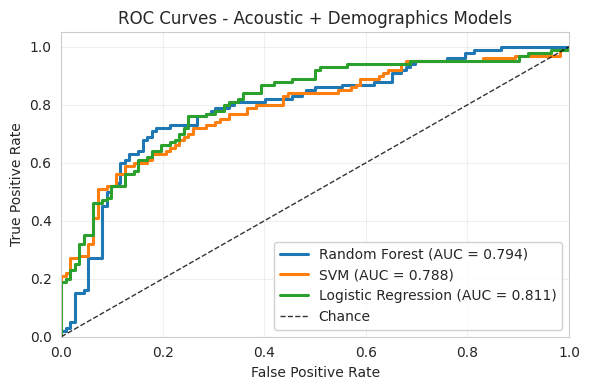

✓ Saved ROC arrays to: roc_segmented_acoustic_plus_demo.npz

--- Model Performance Metrics (With Demographics) ---


,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
Random Forest,0.730,0.759,0.730,0.759,0.745,0.794
SVM,0.760,0.670,0.673,0.758,0.712,0.788
Logistic Regression,0.760,0.750,0.731,0.778,0.755,0.811


In [73]:
# --- STEP 2: Generate all visualizations and tables using the collected results ---

print("\nGenerating visualizations for all models...")

# =====================================================================
# ACOUSTIC-ONLY RESULTS
# =====================================================================
print("\n=== ACOUSTIC-ONLY (No Demographics) ===")
model_results = baseline_results_no_demo

# 📊 Plot 1: Confusion Matrices (one for each model)
plot_confusion_matrices(model_results, figsize=(5 * len(model_results), 4))

# 📈 Plot 2: ROC Curves (all models on one plot)
plot_roc_curves(model_results, title="ROC Curves - Acoustic-Only Models", save_npz_path="roc_segmented_acoustic_only.npz")

# 📋 Table 1: Comprehensive Metrics Table
metrics_df_no_demo, styled_metrics_no_demo = create_metrics_table(model_results)
print("\n--- Model Performance Metrics (Acoustic-Only) ---")
display(styled_metrics_no_demo)

# =====================================================================
# ACOUSTIC + DEMOGRAPHICS RESULTS  
# =====================================================================
print("\n=== ACOUSTIC + DEMOGRAPHICS ===")
model_results = baseline_results_with_demo

# Same plots for demographics version
plot_confusion_matrices(model_results, figsize=(5 * len(model_results), 4))
plot_roc_curves(model_results, title="ROC Curves - Acoustic + Demographics Models", save_npz_path="roc_segmented_acoustic_plus_demo.npz")

metrics_df_with_demo, styled_metrics_with_demo = create_metrics_table(model_results)
print("\n--- Model Performance Metrics (With Demographics) ---")
display(styled_metrics_with_demo)

In [74]:
# =====================================================================
# DEMOGRAPHIC ANALYSIS (using the fixed function from earlier)
# =====================================================================
demographic_and_clinical_cols = [
    'Country', 'Sex', 'Age', 'BMI', 'Breathsounds', 'Breathdifficulty', 
    'Diabetes', 'HIVstatus', 'Durationofcough', 'Priortb', 
    'Hemoptysis', 'Heartrate', 'Temperature', 'Weightloss', 
    'Smokedinlastweek', 'Fever', 'Nightsweats'
]

# =====================================================================
# DEMOGRAPHIC ANALYSIS FOR ALL MODELS
# =====================================================================

print("\n=== DEMOGRAPHIC BREAKDOWN: ALL MODELS ===")

# ---- Loop through ALL models in both conditions ----
for condition, results_dict in [
    ("Acoustic-Only", baseline_results_no_demo),
    ("Acoustic+Demo", baseline_results_with_demo)
]:
    
    print(f"\n--- {condition.upper()} ---")
    
    for model_name in results_dict.keys():
        print(f"\n📊 {model_name}")
        
        # Get this specific model's results
        y_true, y_pred, y_prob = results_dict[model_name]
        
        # Build canonical subject results table
        subject_results_df = pd.DataFrame({
            'y_true': y_true.values,
            'y_pred': y_pred.values,
            'y_prob': y_prob.values
        }, index=y_true.index)
        
        # Run demographic breakdown
        breakdown_df, styled_breakdown = analyze_performance_by_group(
            df, subject_results_df, demographic_and_clinical_cols
        )
        
        print(f"Overall metrics match global table: {breakdown_df.iloc[0].to_dict()}")
        display(style_breakdown_table(breakdown_df, min_n_for_fade=10))
        print("-" * 80)


=== DEMOGRAPHIC BREAKDOWN: ALL MODELS ===

--- ACOUSTIC-ONLY ---

📊 Random Forest

--- In-depth Performance Analysis ---
Overall metrics match global table: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.76, 'Specificity': 0.49107142857142855, 'Accuracy': 0.6179245283018868, 'AUC': 0.6525}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.760,0.491,0.618,0.652
1,Country,IN,13,0.750,0.444,0.538,0.556
2,Country,PH,52,0.600,0.636,0.615,0.642
3,Country,SA,33,0.846,0.650,0.727,0.700
4,Country,UG,56,0.529,0.590,0.571,0.541
5,Country,VN,58,0.972,0.045,0.621,0.694
6,Sex,0,105,0.797,0.488,0.676,0.670
7,Sex,1,107,0.694,0.493,0.561,0.602
8,Age,<25,40,0.857,0.654,0.725,0.690
9,Age,25-35,42,0.529,0.480,0.500,0.518


--------------------------------------------------------------------------------

📊 SVM

--- In-depth Performance Analysis ---
Overall metrics match global table: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.72, 'Specificity': 0.44642857142857145, 'Accuracy': 0.5754716981132075, 'AUC': 0.6639285714285714}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.720,0.446,0.575,0.664
1,Country,IN,13,0.750,0.333,0.462,0.639
2,Country,PH,52,0.600,0.500,0.558,0.612
3,Country,SA,33,0.692,0.600,0.636,0.723
4,Country,UG,56,0.412,0.590,0.536,0.543
5,Country,VN,58,0.972,0.045,0.621,0.701
6,Sex,0,105,0.766,0.390,0.619,0.666
7,Sex,1,107,0.639,0.479,0.533,0.611
8,Age,<25,40,0.571,0.615,0.600,0.643
9,Age,25-35,42,0.588,0.520,0.548,0.562


--------------------------------------------------------------------------------

📊 Logistic Regression

--- In-depth Performance Analysis ---
Overall metrics match global table: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.73, 'Specificity': 0.5357142857142857, 'Accuracy': 0.6273584905660378, 'AUC': 0.7082142857142857}


...

--------------------------------------------------------------------------------

📊 SVM

--- In-depth Performance Analysis ---
Overall metrics match global table: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.76, 'Specificity': 0.6696428571428571, 'Accuracy': 0.7122641509433962, 'AUC': 0.787767857142857}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.760,0.670,0.712,0.788
1,Country,IN,13,0.750,0.333,0.462,0.611
2,Country,PH,52,0.700,0.818,0.750,0.817
3,Country,SA,33,0.538,0.950,0.788,0.731
4,Country,UG,56,0.647,0.795,0.750,0.757
5,Country,VN,58,0.944,0.182,0.655,0.819
6,Sex,0,105,0.859,0.585,0.752,0.817
7,Sex,1,107,0.583,0.718,0.673,0.689
8,Age,<25,40,0.643,0.769,0.725,0.843
9,Age,25-35,42,0.588,0.800,0.714,0.652


--------------------------------------------------------------------------------

📊 Logistic Regression

--- In-depth Performance Analysis ---
Overall metrics match global table: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.76, 'Specificity': 0.75, 'Accuracy': 0.7547169811320755, 'AUC': 0.8107142857142858}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.760,0.750,0.755,0.811
1,Country,IN,13,0.750,0.333,0.462,0.722
2,Country,PH,52,0.700,0.818,0.750,0.836
3,Country,SA,33,0.615,0.850,0.758,0.765
4,Country,UG,56,0.647,0.872,0.804,0.769
5,Country,VN,58,0.917,0.545,0.776,0.843
6,Sex,0,105,0.828,0.634,0.752,0.819
7,Sex,1,107,0.639,0.817,0.757,0.745
8,Age,<25,40,0.714,0.885,0.825,0.827
9,Age,25-35,42,0.412,0.840,0.667,0.680


--------------------------------------------------------------------------------


## MLP + Google TabNet (Underperform)

In [75]:
# =====================================================================
# 4. Advanced Models: MLP + TabNet (No Demographics)
# =====================================================================

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import roc_auc_score

print("=== ADVANCED MODELS (Acoustic-Only) ===")

# ---- 4.1 MLP Builder + Scikit-learn Wrapper ----
def build_mlp(input_shape):
    """Simple but effective MLP"""
    inputs = Input(shape=input_shape)
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

class KerasMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, build_fn, epochs=50, batch_size=32, patience=10):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.model_ = None
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        input_shape = (X.shape[1],)
        self.model_ = self.build_fn(input_shape)
        
        early_stop = EarlyStopping(
            monitor='val_loss', patience=self.patience, 
            restore_best_weights=True
        )
        
        self.model_.fit(X, y,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       validation_split=0.1,
                       callbacks=[early_stop],
                       verbose=0)
        return self

    def predict_proba(self, X):
        probs_class_1 = self.model_.predict(X, verbose=0)
        probs_class_0 = 1.0 - probs_class_1
        return np.hstack((probs_class_0, probs_class_1))

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ---- 4.2 Convert data to numpy (Keras/TabNet prefer arrays) ----
X_train_np = X_train_scaled  # From acoustic-only baseline
X_val_np = X_val_scaled
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

# ---- 4.3 Define advanced models ----
advanced_models_no_demo = {
    "MLP": KerasMLPWrapper(build_mlp, epochs=50, batch_size=32, patience=10),
    "TabNet": TabNetClassifier(
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=1e-3),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='sparsemax',
        seed=42,
        verbose=0
    )
}

# ---- 4.4 Train + evaluate (SAME LOGIC as baselines) ----
advanced_results_no_demo = {}

for name, model in advanced_models_no_demo.items():
    print(f"\n--- Training {name} (No Demographics) ---")
    
    if name == "TabNet":
        model.fit(
            X_train=X_train_np, y_train=y_train_np,
            eval_set=[(X_val_np, y_val_np)],
            eval_name=['validation'],
            eval_metric=['auc'],
            max_epochs=50, patience=10,
            batch_size=32,
            drop_last=False
        )
    else:
        model.fit(X_train_np, y_train_np)
    
    # SAME EVALUATION PIPELINE as baselines
    cough_probs = model.predict_proba(X_val_np)[:, 1]
    
    val_probs_df = pd.DataFrame({
        'subject_id': subjects[val_mask].values,
        'probability': cough_probs,
        'segment_length': acoustic_features_df[val_mask]['segment_length'].values
    })
    
    subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)
    subject_weighted_probs.name = 'probability'
    
    auc_results_df = val_subjects_df.join(subject_weighted_probs).dropna()
    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    print(f"Subject-level AUC: {auc_score:.4f}")
    
    y_true_subject = auc_results_df['label']
    y_prob_subject = auc_results_df['probability']
    y_pred_subject = (y_prob_subject >= 0.5).astype(int)
    
    advanced_results_no_demo[name] = (y_true_subject, y_pred_subject, y_prob_subject)

print("\n✅ Advanced models (No Demo) complete!")

2026-04-17 19:10:23.917574: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 19:10:29.898417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 19:11:54.419853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


=== ADVANCED MODELS (Acoustic-Only) ===

--- Training MLP (No Demographics) ---


2026-04-17 19:13:03.453732: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/scratch/sli21/ipykernel_876171/1582345094.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-level AUC: 0.6508

--- Training TabNet (No Demographics) ---

Early stopping occurred at epoch 35 with best_epoch = 25 and best_validation_auc = 0.56886


/wynton/home/zhang/sli21/.conda/envs/r2d2/lib/python3.9/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Subject-level AUC: 0.6204

✅ Advanced models (No Demo) complete!


/scratch/sli21/ipykernel_876171/1582345094.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


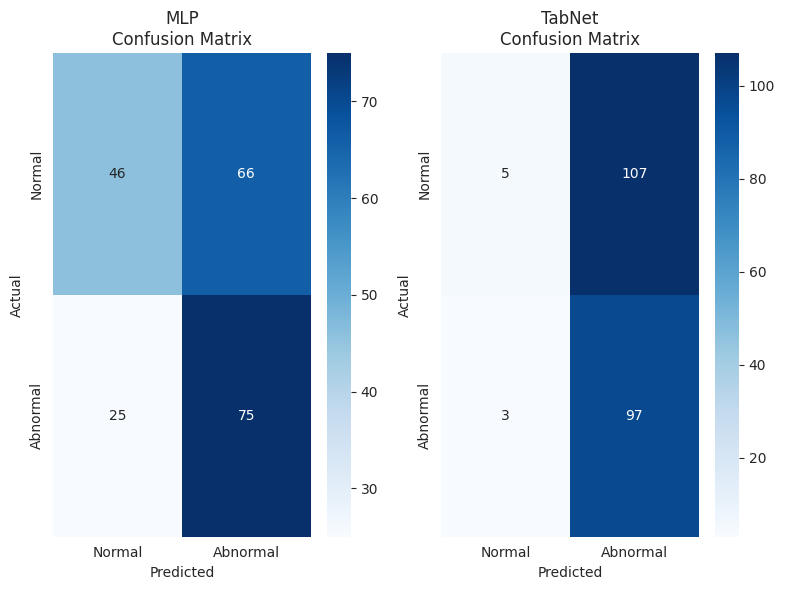

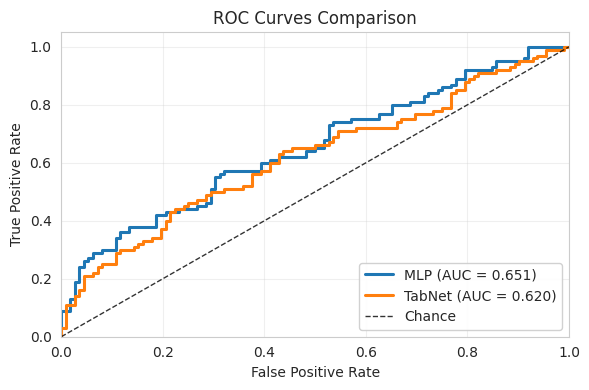

,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
MLP,0.750,0.411,0.532,0.648,0.571,0.651
TabNet,0.970,0.045,0.475,0.625,0.481,0.620


In [76]:
# Your existing visualization code NOW WORKS with advanced models too:
plot_confusion_matrices(advanced_results_no_demo)
plot_roc_curves(advanced_results_no_demo)
metrics_advanced, styled_advanced = create_metrics_table(advanced_results_no_demo)
display(styled_advanced)


In [77]:
# =====================================================================
# 4. Advanced Models: MLP + TabNet (With Demographics)
# =====================================================================

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import roc_auc_score

print("=== ADVANCED MODELS (Acoustic + Demographics) ===")

# ---- 4.2 Convert data to numpy (Keras/TabNet prefer arrays) ----
X_train_np = X_train_demo_scaled  # From acoustic-only baseline
X_val_np = X_val_demo_scaled
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

# ---- 4.3 Define advanced models ----
advanced_models_no_demo = {
    "MLP": KerasMLPWrapper(build_mlp, epochs=50, batch_size=32, patience=10),
    "TabNet": TabNetClassifier(
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=1e-3),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='sparsemax',
        seed=42,
        verbose=0
    )
}

# ---- 4.4 Train + evaluate (SAME LOGIC as baselines) ----
advanced_results_no_demo = {}

for name, model in advanced_models_no_demo.items():
    print(f"\n--- Training {name} (No Demographics) ---")
    
    if name == "TabNet":
        model.fit(
            X_train=X_train_np, y_train=y_train_np,
            eval_set=[(X_val_np, y_val_np)],
            eval_name=['validation'],
            eval_metric=['auc'],
            max_epochs=50, patience=10,
            batch_size=32,
            drop_last=False
        )
    else:
        model.fit(X_train_np, y_train_np)
    
    # SAME EVALUATION PIPELINE as baselines
    cough_probs = model.predict_proba(X_val_np)[:, 1]
    
    val_probs_df = pd.DataFrame({
        'subject_id': subjects_demo[val_mask_demo].values,
        'probability': cough_probs,
        'segment_length': acoustic_features_df[val_mask]['segment_length'].values
    })
    
    subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)
    subject_weighted_probs.name = 'probability'
    
    auc_results_df = val_subjects_demo_df.join(subject_weighted_probs).dropna()
    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    print(f"Subject-level AUC: {auc_score:.4f}")
    
    y_true_subject = auc_results_df['label']
    y_prob_subject = auc_results_df['probability']
    y_pred_subject = (y_prob_subject >= 0.5).astype(int)
    
    advanced_results_no_demo[name] = (y_true_subject, y_pred_subject, y_prob_subject)

print("\n✅ Advanced models (No Demo) complete!")

=== ADVANCED MODELS (Acoustic + Demographics) ===

--- Training MLP (No Demographics) ---


/scratch/sli21/ipykernel_876171/3810374361.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)


Subject-level AUC: 0.5949

--- Training TabNet (No Demographics) ---
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_validation_auc = 0.57729


/wynton/home/zhang/sli21/.conda/envs/r2d2/lib/python3.9/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Subject-level AUC: 0.6177

✅ Advanced models (No Demo) complete!


/scratch/sli21/ipykernel_876171/3810374361.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_weighted_probs = val_probs_df.groupby('subject_id').apply(weighted_mean_probs)
